
Model Comparison:
                        MSE       MAE  R2 Score
Linear Regression  3.724565  1.552128  0.993849
Ridge Regression   6.408269  1.994021  0.989417
Lasso Regression   9.994534  2.428571  0.983494


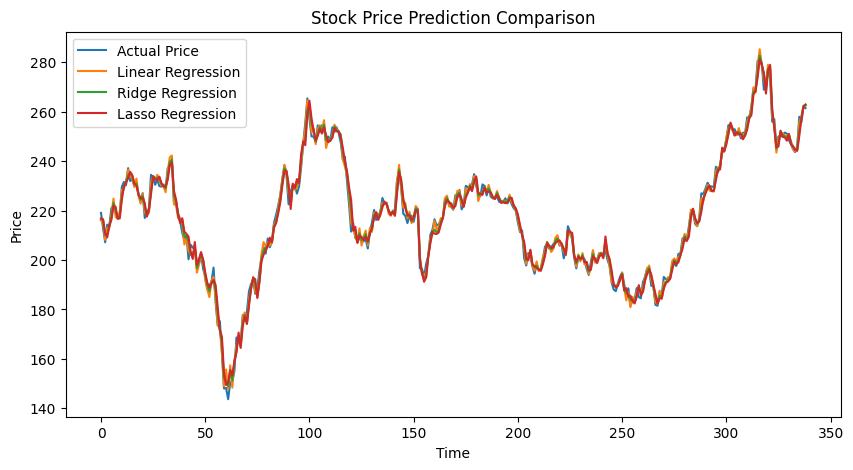

In [ ]:
# Step 11: Comparison Table
# ===============================
results_df = pd.DataFrame(results, index=["MSE", "MAE", "R2 Score"]).T
print("\nModel Comparison:")
print(results_df)

# ===============================
# Step 12: Visualization
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Price')

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    plt.plot(y_pred, label=name)

plt.title("Stock Price Prediction Comparison")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [5]:
from google.colab import files
uploaded = files.upload()

Saving Tesla.csv - Tesla.csv.csv to Tesla.csv - Tesla.csv.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [7]:
df = pd.read_csv('Tesla.csv - Tesla.csv.csv')
print(df.head())
print(df.info())
print(df.describe())

        Date       Open   High        Low      Close    Volume  Adj Close
0  6/29/2010  19.000000  25.00  17.540001  23.889999  18766300  23.889999
1  6/30/2010  25.790001  30.42  23.299999  23.830000  17187100  23.830000
2   7/1/2010  25.000000  25.92  20.270000  21.959999   8218800  21.959999
3   7/2/2010  23.000000  23.10  18.709999  19.200001   5139800  19.200001
4   7/6/2010  20.000000  20.00  15.830000  16.110001   6866900  16.110001
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1692 non-null   object 
 1   Open       1692 non-null   float64
 2   High       1692 non-null   float64
 3   Low        1692 non-null   float64
 4   Close      1692 non-null   float64
 5   Volume     1692 non-null   int64  
 6   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 92.7+ KB
None
              Open    

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Handle missing values
df = df.dropna()

In [9]:
# Create new feature: Price Range
df['Price_Range'] = df['High'] - df['Low']

# Features & Target
X = df[['Open', 'High', 'Low', 'Volume', 'Price_Range']]
y = df['Close']

In [10]:
# Step 7: Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [11]:
#Step 8: Feature Scaling
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# Step 9: Models
# ===============================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1)}

In [15]:
results = {}

# ===============================
# Step 10: Training + Evaluation
# ===============================
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = [mse, mae, r2]

    print(f"\n{name}")
    print("MSE:", mse)
    print("MAE:", mae)
    print("R2 Score:", r2)



Linear Regression
MSE: 3.724565103750804
MAE: 1.552128134747091
R2 Score: 0.9938490105057245

Ridge Regression
MSE: 6.408269110407728
MAE: 1.9940206590548208
R2 Score: 0.9894169668467029

Lasso Regression
MSE: 9.994533720915035
MAE: 2.4285705267167867
R2 Score: 0.9834943757982318


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.724e+03, tolerance: 1.174e+03
  model = cd_fast.enet_coordinate_descent(



Model Comparison:
                        MSE       MAE  R2 Score
Linear Regression  3.724565  1.552128  0.993849
Ridge Regression   6.408269  1.994021  0.989417
Lasso Regression   9.994534  2.428571  0.983494


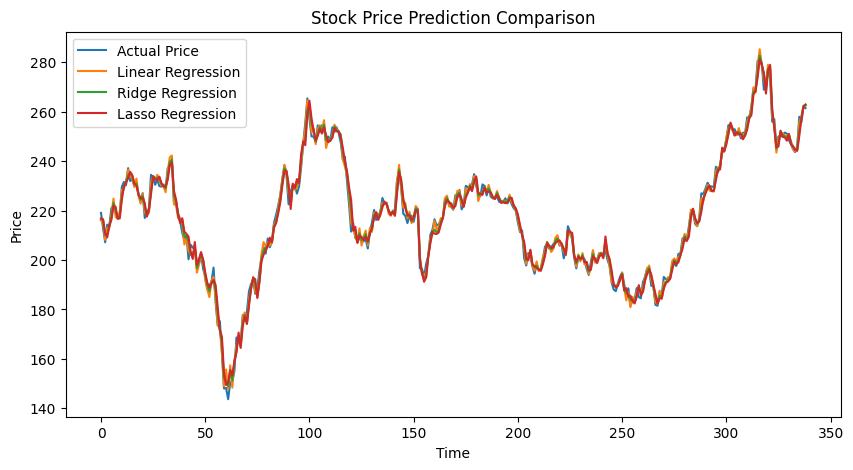

In [16]:
# Step 11: Comparison Table
# ===============================
results_df = pd.DataFrame(results, index=["MSE", "MAE", "R2 Score"]).T
print("\nModel Comparison:")
print(results_df)

# ===============================
# Step 12: Visualization
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Price')

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    plt.plot(y_pred, label=name)

plt.title("Stock Price Prediction Comparison")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()